# Concrete Compressive Strength Prediction

Predicting the 28-day (and any-age) compressive strength of concrete from its mix design, using classical ML and deep learning.

**Why it matters:** lab testing a concrete mix takes days to weeks (cylinders are crushed at 7, 28, 90 days). A reliable model lets engineers screen mix designs before pouring a single sample.

**Dataset:** [UCI Concrete Compressive Strength](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength) (Yeh, 1998). 1,030 lab-tested mixes, 8 inputs (kg/m³ of each ingredient + age in days), target = strength in MPa.

**Pipeline**
1. Exploratory data analysis
2. Cleaning (duplicates) and domain-driven feature engineering (water–cement ratio, water–binder ratio, log-age)
3. Baselines: mean predictor, linear regression
4. Tree ensembles: Random Forest, Gradient Boosting, XGBoost (5-fold CV + hyperparameter search)
5. Deep neural network (Keras) with input normalisation and early stopping
6. Held-out test evaluation (MAE, RMSE, R²)
7. Explainability with SHAP
8. Saving the final model and a reusable `predict_strength()` function

## 1. Setup

In [ ]:
# ---- Google Colab setup (safe to run anywhere) ----
# Installs SHAP if missing and downloads the dataset if concrete_data.csv isn't uploaded.
import os, importlib.util
if importlib.util.find_spec("shap") is None:
    %pip install -q shap

if not os.path.exists("concrete_data.csv"):
    import pandas as pd
    url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv"
    raw = pd.read_csv(url)
    raw.columns = ["cement", "blast_furnace_slag", "fly_ash", "water", "superplasticizer",
                   "coarse_aggregate", "fine_aggregate", "age", "concrete_compressive_strength"]
    raw.to_csv("concrete_data.csv", index=False)
    print("Downloaded dataset:", raw.shape)
else:
    print("Using local concrete_data.csv")

In [1]:
import warnings, os, random
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Plot style
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.edgecolor": "#b5b4ad", "axes.labelcolor": "#0b0b0b",
    "xtick.color": GRAY, "ytick.color": GRAY, "axes.titleweight": "bold",
})
DIVERGING = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", ORANGE])

## 2. Load data

In [2]:
DATA_PATH = "concrete_data.csv"   # change if your file is elsewhere

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()            # strip stray whitespace from column names
TARGET = "concrete_compressive_strength"
print(df.shape)
df.head()

(1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.2,104.5,102.0,192.4,272.9,350.0,540.0
blast_furnace_slag,1030.0,73.9,86.3,0.0,0.0,22.0,143.0,359.4
fly_ash,1030.0,54.2,64.0,0.0,0.0,0.0,118.3,200.1
water,1030.0,181.6,21.4,121.8,164.9,185.0,192.0,247.0
superplasticizer,1030.0,6.2,6.0,0.0,0.0,6.4,10.2,32.2
coarse_aggregate,1030.0,972.9,77.8,801.0,932.0,968.0,1029.4,1145.0
fine_aggregate,1030.0,773.6,80.2,594.0,731.0,779.5,824.0,992.6
age,1030.0,45.7,63.2,1.0,7.0,28.0,56.0,365.0
concrete_compressive_strength,1030.0,35.8,16.7,2.3,23.7,34.4,46.1,82.6


## 3. Exploratory data analysis

In [5]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Missing values: 0
Duplicate rows: 25


There are no missing values, but **25 exact duplicate rows**. If kept, the same mix can land in both train and test sets and inflate the score, so they are removed.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("After removing duplicates:", df.shape)

After removing duplicates: (1005, 9)


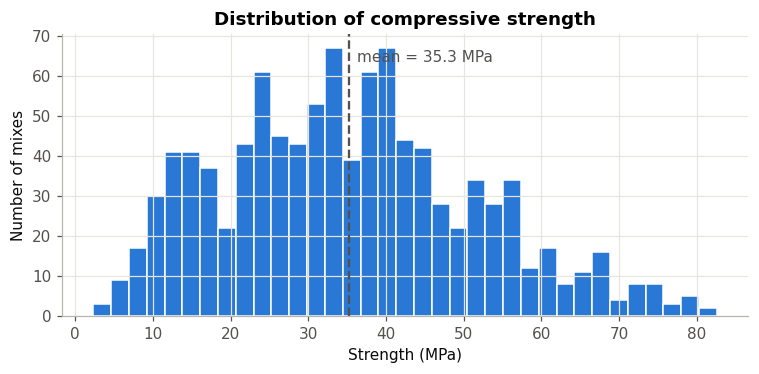

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(df[TARGET], bins=35, color=BLUE, edgecolor="white", linewidth=1)
ax.axvline(df[TARGET].mean(), color=GRAY, ls="--", lw=1.5)
ax.text(df[TARGET].mean() + 1, ax.get_ylim()[1] * 0.9, f"mean = {df[TARGET].mean():.1f} MPa", color=GRAY)
ax.set(title="Distribution of compressive strength", xlabel="Strength (MPa)", ylabel="Number of mixes")
plt.tight_layout(); plt.show()

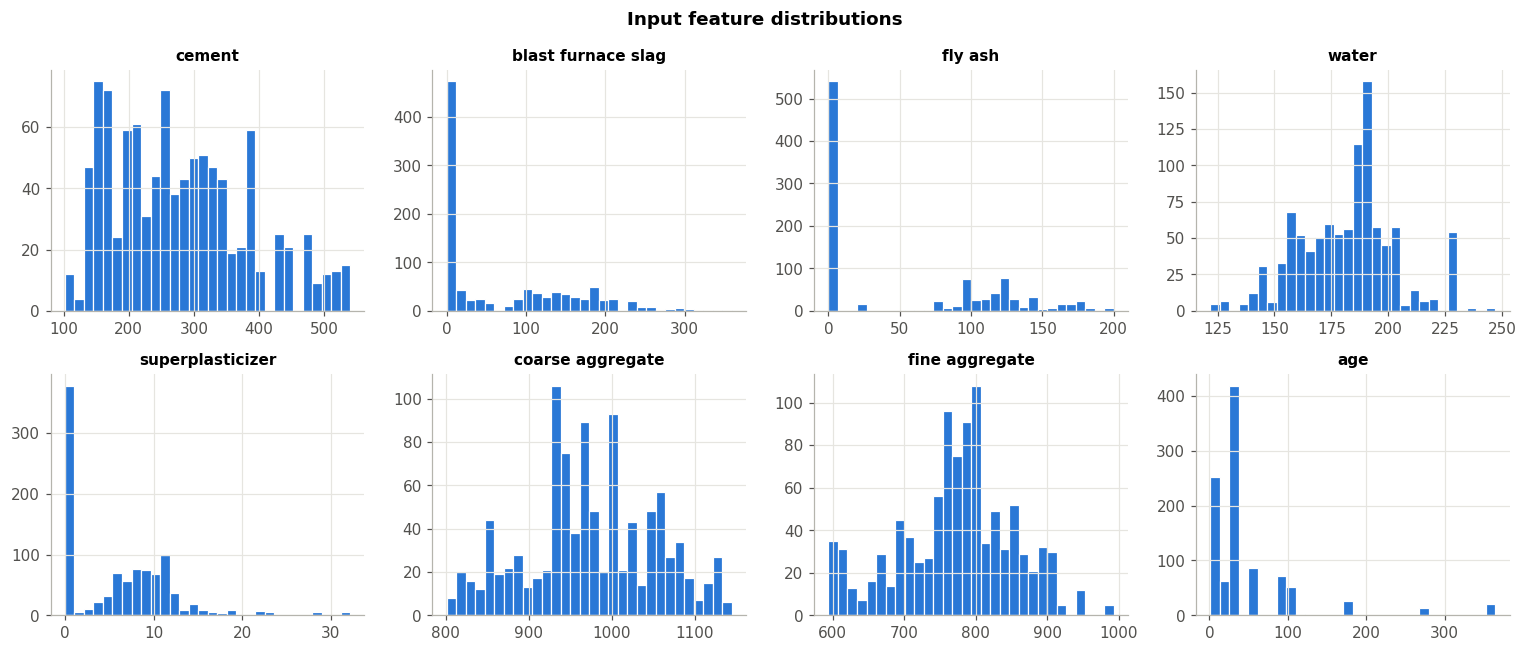

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), df.columns.drop(TARGET)):
    ax.hist(df[col], bins=30, color=BLUE, edgecolor="white", linewidth=0.8)
    ax.set_title(col.replace("_", " "), fontsize=10)
fig.suptitle("Input feature distributions", fontweight="bold")
plt.tight_layout(); plt.show()

Slag, fly ash and superplasticizer are zero for many mixes (they are optional ingredients), and **age is heavily skewed** (most tests at 28 days, a few up to 365). The skew in age motivates a log transform later.

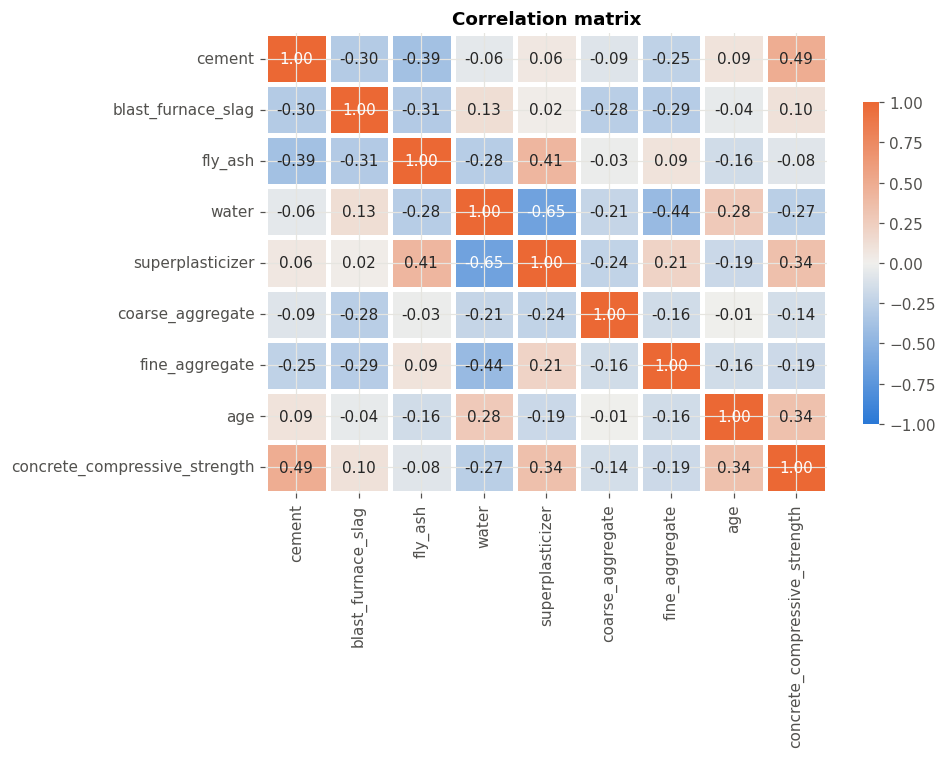

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1,
            linewidths=2, linecolor="white", cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout(); plt.show()

Cement (+0.49), superplasticizer (+0.34) and age (+0.34) are the strongest linear drivers; water is negative (−0.27). Linear correlations are modest, which already hints that the relationship is **non-linear** and tree / neural models should beat linear regression.

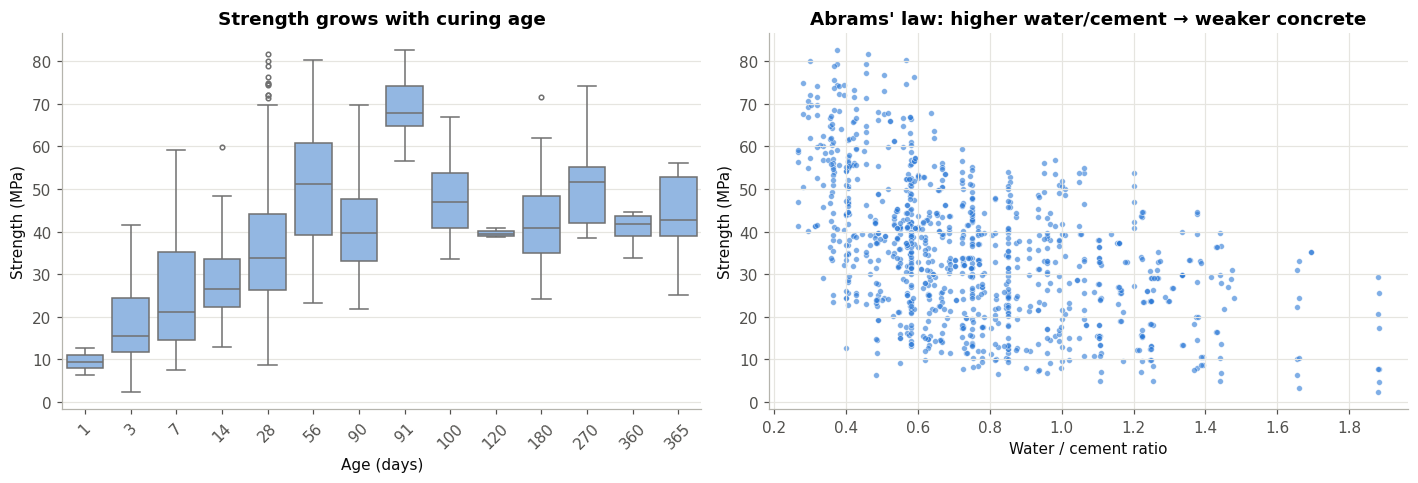

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="age", y=TARGET, color="#86b6ef", ax=axes[0], fliersize=3)
axes[0].set(title="Strength grows with curing age", xlabel="Age (days)", ylabel="Strength (MPa)")
axes[0].tick_params(axis="x", rotation=45)

wc = df["water"] / df["cement"]
axes[1].scatter(wc, df[TARGET], s=14, alpha=0.6, color=BLUE, edgecolors="white", linewidths=0.4)
axes[1].set(title="Abrams' law: higher water/cement → weaker concrete",
            xlabel="Water / cement ratio", ylabel="Strength (MPa)")
plt.tight_layout(); plt.show()

Two well-known civil-engineering relationships show up clearly:
- **Strength rises with age** quickly up to ~28 days, then flattens (hydration slows).
- **Abrams' law:** strength falls as the water–cement ratio rises. This ratio is a much stronger single predictor than water or cement alone, so it is engineered as a feature.

**On outliers:** the boxplot "outliers" (e.g. age = 365 days, high slag) are real lab measurements, not errors. Deleting them would just shrink the range the model can predict for, so they are kept.

## 4. Feature engineering

In [11]:
def add_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["binder"] = d["cement"] + d["blast_furnace_slag"] + d["fly_ash"]   # total cementitious material
    d["water_cement_ratio"] = d["water"] / d["cement"]
    d["water_binder_ratio"] = d["water"] / d["binder"]
    d["sp_binder_ratio"] = d["superplasticizer"] / d["binder"]
    d["agg_binder_ratio"] = (d["coarse_aggregate"] + d["fine_aggregate"]) / d["binder"]
    d["log_age"] = np.log1p(d["age"])
    return d

X = add_features(df.drop(columns=TARGET))
y = df[TARGET]

print(X.shape)
X.corrwith(y).sort_values(key=abs, ascending=False).round(2)

(1005, 14)


water_binder_ratio   -0.61
binder                0.60
log_age               0.56
agg_binder_ratio     -0.55
water_cement_ratio   -0.49
cement                0.49
superplasticizer      0.34
age                   0.34
water                -0.27
sp_binder_ratio       0.22
fine_aggregate       -0.19
coarse_aggregate     -0.14
blast_furnace_slag    0.10
fly_ash              -0.08
dtype: float64

The engineered `water_binder_ratio` and `water_cement_ratio` are now the most correlated features with strength, and `log_age` correlates better than raw `age`.

## 5. Train / test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (804, 14)  Test: (201, 14)


The test set (20%) is held out and used **only once**, at the end. All model selection uses 5-fold cross-validation on the training set.

## 6. Baselines and classical models (5-fold CV)

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Linear Regression": Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=SEED),
    "XGBoost (default)": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=SEED, n_jobs=-1),
}

rows = []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"Model": name,
                 "CV MAE": -s["test_MAE"].mean(),
                 "CV RMSE": -s["test_RMSE"].mean(),
                 "CV R2": s["test_R2"].mean(),
                 "R2 std": s["test_R2"].std()})
cv_results = pd.DataFrame(rows).set_index("Model").round(3)
cv_results

,CV MAE,CV RMSE,CV R2,R2 std
Model,,,,
Mean baseline,12.971,16.028,-0.010,0.013
Linear Regression,5.306,6.792,0.818,0.017
Random Forest,3.514,5.016,0.901,0.005
Gradient Boosting,2.989,4.416,0.923,0.008
XGBoost (default),2.983,4.520,0.920,0.008


Predicting the mean gives MAE ≈ 13 MPa, which is the bar any model must clear. Linear regression more than halves that error, and tree ensembles cut it by roughly 4×, confirming the relationship is strongly non-linear.

### Hyperparameter tuning (XGBoost)

In [14]:
param_dist = {
    "n_estimators": [400, 600, 800, 1000, 1500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0],
    "reg_lambda": [0.1, 1, 3, 10],
}
search = RandomizedSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist, n_iter=40, cv=cv,
    scoring="neg_mean_absolute_error", random_state=SEED, n_jobs=1, verbose=0,
)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_
print("Best CV MAE: %.3f MPa" % -search.best_score_)
print("Best params:", search.best_params_)

Best CV MAE: 2.756 MPa
Best params: {'subsample': 0.6, 'reg_lambda': 10, 'n_estimators': 1500, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


## 7. Deep neural network (Keras)

Design choices for the network:
- **Input normalisation** (a `Normalization` layer learned from training data). Features are on very different scales (cement ~100–540 kg/m³, superplasticizer ~0–32 kg/m³), and without scaling, gradient descent struggles to converge.
- A wider-then-narrower architecture (128 → 64 → 32) with light dropout (0.1) for regularisation, Adam optimiser, batch size 32.
- **Early stopping** on a validation split, restoring the best weights, plus learning-rate reduction on plateau, so the number of epochs is chosen by the data rather than guessed.

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(SEED); keras.utils.set_random_seed(SEED)

X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_train.values.astype("float32"), y_train.values.astype("float32"),
    test_size=0.15, random_state=SEED)

def build_dnn(n_features, norm_data):
    norm = layers.Normalization()
    norm.adapt(norm_data)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        norm,
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

dnn = build_dnn(X_train.shape[1], X_tr_nn)
dnn.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_mae", patience=60, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=25, min_lr=1e-5),
]
history = dnn.fit(X_tr_nn, y_tr_nn, validation_data=(X_val_nn, y_val_nn),
                  epochs=1000, batch_size=32, callbacks=callbacks, verbose=0)
print("Stopped after", len(history.history["loss"]), "epochs")
print("Best validation MAE: %.3f MPa" % min(history.history["val_mae"]))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 14)             │            29 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,318 (48.12 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 29 (120.00 B)

Stopped after 418 epochs
Best validation MAE: 2.948 MPa


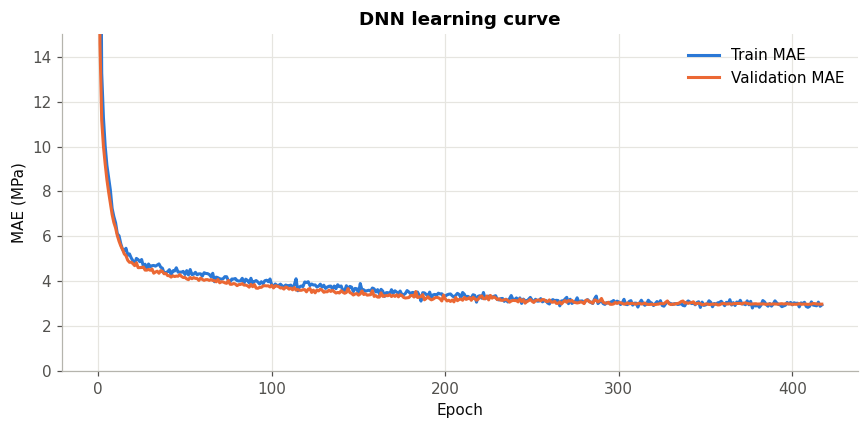

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["mae"], color=BLUE, lw=2, label="Train MAE")
ax.plot(history.history["val_mae"], color=ORANGE, lw=2, label="Validation MAE")
ax.set(title="DNN learning curve", xlabel="Epoch", ylabel="MAE (MPa)", ylim=(0, 15))
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 8. Final evaluation on the held-out test set

In [17]:
def metrics(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred)}

final_models = {
    "Mean baseline": models["Mean baseline"],
    "Linear Regression": models["Linear Regression"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"],
    "XGBoost (tuned)": best_xgb,
}
test_rows, preds = [], {}
for name, m in final_models.items():
    if name != "XGBoost (tuned)":
        m.fit(X_train, y_train)
    preds[name] = m.predict(X_test)
    test_rows.append({"Model": name, **metrics(y_test, preds[name])})

preds["Keras DNN"] = dnn.predict(X_test.values.astype("float32"), verbose=0).ravel()
test_rows.append({"Model": "Keras DNN", **metrics(y_test, preds["Keras DNN"])})

test_results = pd.DataFrame(test_rows).set_index("Model").round(3).sort_values("MAE")
test_results

,MAE,RMSE,R2
Model,,,
XGBoost (tuned),2.587,4.108,0.943
Gradient Boosting,2.693,4.119,0.943
Keras DNN,2.938,4.309,0.938
Random Forest,3.523,4.950,0.918
Linear Regression,5.676,7.383,0.817
Mean baseline,13.972,17.296,-0.003


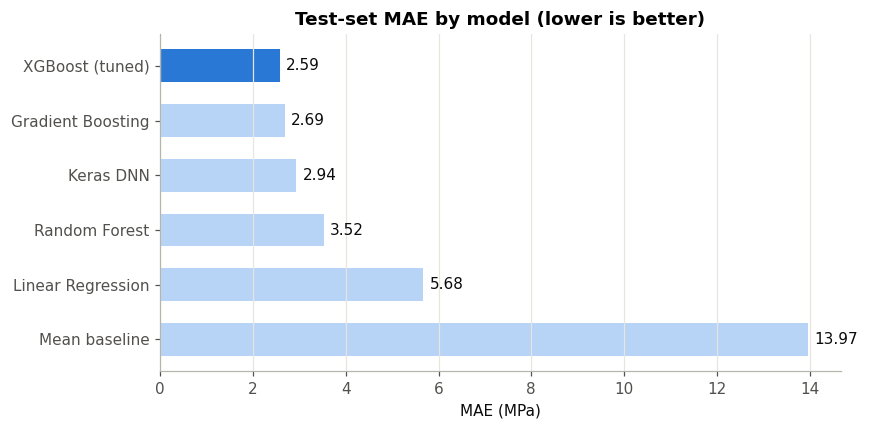

In [18]:
order = test_results.sort_values("MAE", ascending=False)
colors = [BLUE if n == order["MAE"].idxmin() else "#b7d3f6" for n in order.index]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(order.index, order["MAE"], color=colors, height=0.6)
ax.bar_label(bars, fmt="%.2f", padding=4, color="#0b0b0b")
ax.set(title="Test-set MAE by model (lower is better)", xlabel="MAE (MPa)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

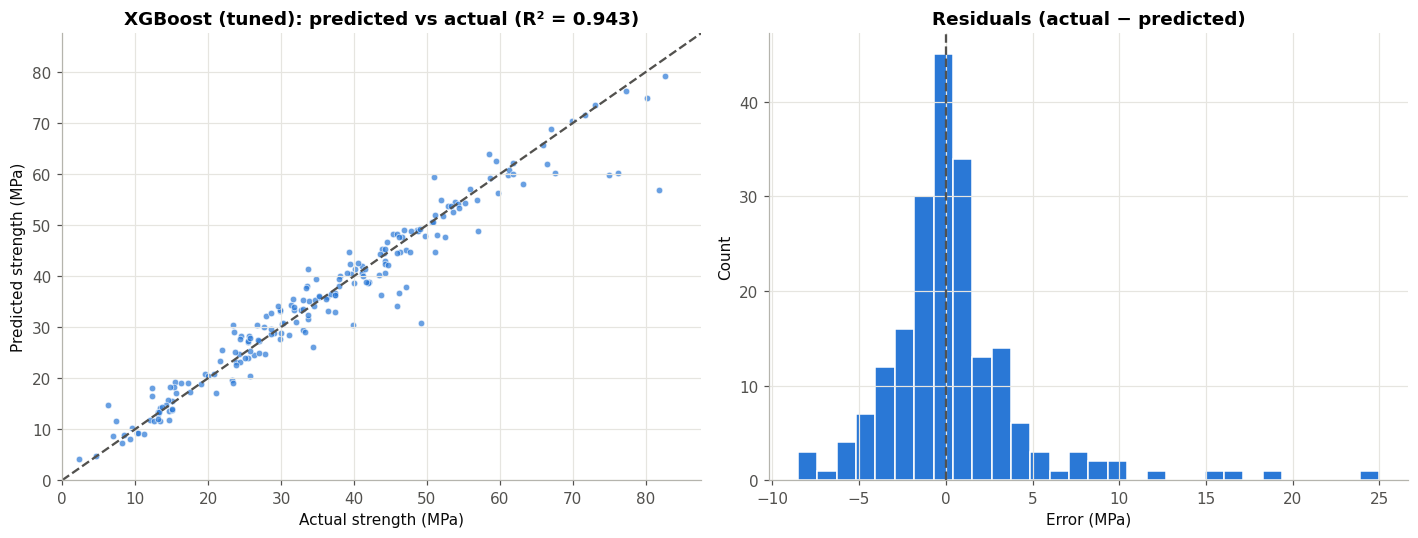

88% of test predictions are within ±5 MPa of the lab value


In [19]:
best_name = test_results["MAE"].idxmin()
p = preds[best_name]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lims = [0, max(y_test.max(), p.max()) + 5]
axes[0].scatter(y_test, p, s=18, alpha=0.7, color=BLUE, edgecolors="white", linewidths=0.5)
axes[0].plot(lims, lims, color=GRAY, ls="--", lw=1.5)
axes[0].set(xlim=lims, ylim=lims, xlabel="Actual strength (MPa)", ylabel="Predicted strength (MPa)",
            title=f"{best_name}: predicted vs actual (R² = {r2_score(y_test, p):.3f})")

resid = y_test - p
axes[1].hist(resid, bins=30, color=BLUE, edgecolor="white")
axes[1].axvline(0, color=GRAY, ls="--", lw=1.5)
axes[1].set(title="Residuals (actual − predicted)", xlabel="Error (MPa)", ylabel="Count")
plt.tight_layout(); plt.show()

print(f"{(np.abs(resid) <= 5).mean():.0%} of test predictions are within ±5 MPa of the lab value")

## 9. Explainability with SHAP

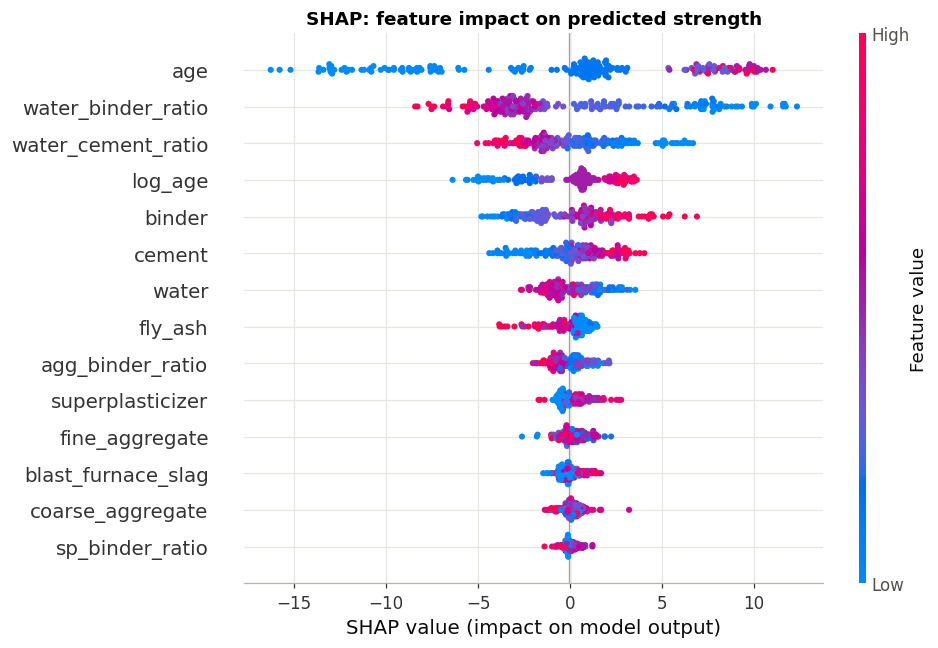

In [20]:
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False, plot_size=(9, 6))
plt.title("SHAP: feature impact on predicted strength")
plt.tight_layout(); plt.show()

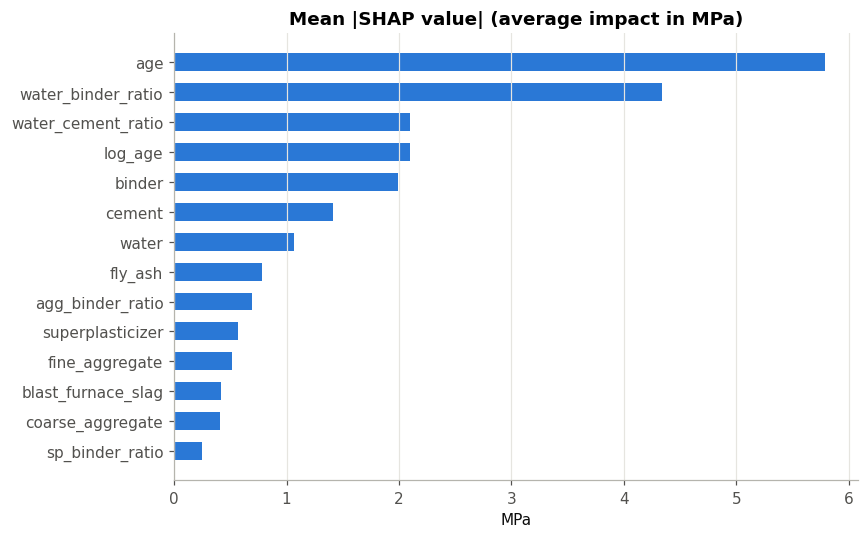

age                   5.79
water_binder_ratio    4.34
water_cement_ratio    2.10
log_age               2.10
binder                1.99
cement                1.42
water                 1.06
fly_ash               0.78
agg_binder_ratio      0.70
superplasticizer      0.57
fine_aggregate        0.51
blast_furnace_slag    0.42
coarse_aggregate      0.40
sp_binder_ratio       0.25
dtype: float32

In [21]:
importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index, importance.values, color=BLUE, height=0.6)
ax.set(title="Mean |SHAP value| (average impact in MPa)", xlabel="MPa")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
importance.sort_values(ascending=False).round(2)

**Takeaways**
- **Age (log-age)** is the single biggest driver: young concrete is weak, and strength climbs quickly in the first 28 days.
- **Water–binder / water–cement ratio** comes next, confirming Abrams' law: less water per unit of binder → stronger concrete.
- The model has learned physically sensible relationships, which is important before trusting it for mix-design screening.

## 10. Save the model and predict for a new mix

In [22]:
import joblib
joblib.dump(best_xgb, "concrete_strength_xgb.joblib")

def predict_strength(cement, blast_furnace_slag, fly_ash, water, superplasticizer,
                     coarse_aggregate, fine_aggregate, age, model=best_xgb):
    """Predict compressive strength (MPa). Quantities in kg/m³, age in days."""
    row = pd.DataFrame([dict(cement=cement, blast_furnace_slag=blast_furnace_slag, fly_ash=fly_ash,
                             water=water, superplasticizer=superplasticizer,
                             coarse_aggregate=coarse_aggregate, fine_aggregate=fine_aggregate, age=age)])
    return float(model.predict(add_features(row)[X.columns])[0])

# Example: the same mix tested at different ages
for age in [3, 7, 28, 90]:
    print(f"Age {age:>3} days → {predict_strength(380, 95, 0, 228, 0, 932, 594, age):.1f} MPa")

Age   3 days → 24.9 MPa
Age   7 days → 32.9 MPa
Age  28 days → 36.8 MPa
Age  90 days → 40.1 MPa


## 11. Conclusion

| Model | Test MAE (MPa) | Test R² |
|---|---|---|
| Mean baseline | 13.97 | 0.000 |
| Linear Regression | 5.68 | 0.817 |
| Random Forest | 3.52 | 0.918 |
| Keras DNN | 2.94 | 0.938 |
| Gradient Boosting | 2.69 | 0.943 |
| **XGBoost (tuned)** | **2.59** | **0.943** |

- The tuned **XGBoost** model predicts compressive strength with an average error of **2.59 MPa** and explains **94.3%** of the variance on unseen mixes, a ~5× error reduction over the mean baseline.
- 88% of test predictions fall within ±5 MPa of the lab-measured value.
- SHAP confirms the model relies on physically meaningful drivers: curing age and water–binder ratio.

**Limitations and next steps**
- 1,005 unique samples from a single lab (Taiwan); performance on other cement types / aggregates is unknown.
- Could add prediction intervals (quantile regression) so engineers see uncertainty, not just a point estimate.
- Could be wrapped in a small Streamlit app for interactive mix-design exploration.